# DK1 Theoretical Payload vs Reach

Uses MuJoCo inverse dynamics to compute arm gravity torques and determines maximum payload capacity at each reach for:
- **Nominal torque**: 9 Nm — arm can hold indefinitely (static/continuous payload)
- **Peak torque**: 27 Nm — arm can briefly support for repositioning (transient payload)

**Joint 2** (shoulder pitch, Y-axis) is the limiting joint.

**Worst-case pose**: for each reach R, the configuration that maximises the gravitational load on joint 2 (arm as horizontal as possible).

**Sign convention**:
- `qfrc_inverse[JOINT2_IDX] < 0` when the arm points forward/horizontally
- `available_torque = τ_limit + τ_arm2`  (= τ_limit − |τ_arm2|)
- `max_payload = max(0, available_torque / (g × moment_arm))`

---
**Workflow**: Run **Setup** and **Simulation** cells once (slow). Then iterate on **Plotting** freely.

## Setup — imports, constants, helpers

In [11]:
from __future__ import annotations

import sys
from pathlib import Path

import mujoco
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ── project path ──────────────────────────────────────────────────────────────
ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT))

from trlc_dk1_control.gravity_comp import GravityCompensator  # noqa: E402

print(f"ROOT: {ROOT}")

ROOT: /Users/jvg/Documents/TRLC_Local/TRLC-Coding/trlc-dk1


In [12]:
# ── constants ─────────────────────────────────────────────────────────────────
URDF_PATH = str(ROOT / "urdf/follower/TRLC-DK1-Follower.urdf")
OUT_PATH  = Path("payload_reach_chart.png")  # saved relative to notebook

G          = 9.81   # m/s²
JOINT2_IDX = 1      # 0-based DoF index for joint 2

NOMINAL_NM = 9.0    # Joint 2 continuous torque limit (Nm)
PEAK_NM    = 27.0   # Joint 2 peak torque limit (Nm)

# x-position of joint 2 in world frame when joint 1 = 0
# (base → joint1 z=0.0615, joint1→joint2 x=0.02)
JOINT2_X_WORLD = 0.02  # metres

# Offset from link6-7 origin to tool0 in link6-7's local frame (URDF fixed joint)
_TOOL0_LOCAL = np.array([0.158, 0.0, 0.0])

# z range for tool0 in world frame
Z_MIN = 0.0    # metres
Z_MAX = 0.50   # metres

# Reach range to evaluate
# Max reach is ~0.78 m (arm fully extended: θ₂=π, θ₃=π)
REACH_VALUES = np.linspace(0.10, 0.75, 100)  # metres

# Joint limits for IK — must stay within URDF limits to avoid MuJoCo
# applying constraint penalty forces that corrupt qfrc_inverse.
# URDF limits: joint2 [-0.01, π], joint3 [-0.01, 4.71], joint4 [-111.7°, 90°]
J2_LIM = (0.0, np.pi)
J3_LIM = (0.0, np.pi)
J4_LIM = (np.radians(-100.0), np.radians(90.0))

IK_TOL = 5e-3  # metres

In [13]:
# ── helper functions ──────────────────────────────────────────────────────────

def _link67_id(gc: GravityCompensator) -> int:
    return gc.mj_model.body("link6-7").id


def _apply_theta234(gc: GravityCompensator, theta234: np.ndarray) -> None:
    """Set qpos: joint1=0, joints 2–4 from theta234, rest 0."""
    gc.mj_data.qpos[:] = 0.0
    gc.mj_data.qpos[JOINT2_IDX]     = theta234[0]
    gc.mj_data.qpos[JOINT2_IDX + 1] = theta234[1]
    gc.mj_data.qpos[JOINT2_IDX + 2] = theta234[2]


def _tool0_xz(gc: GravityCompensator, theta234: np.ndarray, body_id: int) -> tuple[float, float]:
    """FK: world-frame (x, z) of tool0 (link6-7 + fixed 0.158 m offset)."""
    _apply_theta234(gc, theta234)
    mujoco.mj_kinematics(gc.mj_model, gc.mj_data)
    pos = gc.mj_data.xpos[body_id]
    rot = gc.mj_data.xmat[body_id].reshape(3, 3)
    p = pos + rot @ _TOOL0_LOCAL
    return float(p[0]), float(p[2])


def _tau_arm2(gc: GravityCompensator, theta234: np.ndarray) -> float:
    """Gravity torque at joint 2 via MuJoCo inverse dynamics."""
    q6 = np.zeros(6)
    q6[JOINT2_IDX]     = theta234[0]
    q6[JOINT2_IDX + 1] = theta234[1]
    q6[JOINT2_IDX + 2] = theta234[2]
    return float(gc.compute(q6)[JOINT2_IDX])


def ik_worst_case(
    gc: GravityCompensator,
    target_reach: float,
    warm_start: np.ndarray | None = None,
) -> np.ndarray | None:
    """
    Find (θ₂, θ₃, θ₄) that:
      - places tool0 at x = target_reach  (equality constraint)
      - keeps tool0 z in [Z_MIN, Z_MAX]   (inequality constraints)
      - MINIMISES τ_arm2                   (worst-case for payload capacity)
    """
    body_id = _link67_id(gc)

    def objective(x):     return _tau_arm2(gc, x)
    def reach_error(x):   return _tool0_xz(gc, x, body_id)[0] - target_reach
    def z_lower(x):       return _tool0_xz(gc, x, body_id)[1] - Z_MIN
    def z_upper(x):       return Z_MAX - _tool0_xz(gc, x, body_id)[1]

    constraints = [
        {"type": "eq",   "fun": reach_error},
        {"type": "ineq", "fun": z_lower},
        {"type": "ineq", "fun": z_upper},
    ]
    bounds  = [J2_LIM, J3_LIM, J4_LIM]
    options = {"ftol": 1e-9, "maxiter": 600}

    init_conditions: list[np.ndarray] = []
    if warm_start is not None:
        init_conditions.append(warm_start.copy())
    for t2 in np.linspace(np.pi / 4, np.pi, 5):
        for t3 in np.linspace(0.0, np.pi, 5):
            for t4 in np.radians([-30.0, 0.0, 30.0]):
                init_conditions.append(np.array([t2, t3, t4]))

    best_x: np.ndarray | None = None
    best_val = np.inf

    for x0 in init_conditions:
        try:
            res = minimize(
                objective, x0, method="SLSQP",
                bounds=bounds, constraints=constraints, options=options,
            )
        except Exception:
            continue
        if abs(reach_error(res.x)) > IK_TOL:                    continue
        if z_lower(res.x) < -IK_TOL or z_upper(res.x) < -IK_TOL: continue
        val = objective(res.x)
        if val < best_val:
            best_val = val
            best_x   = res.x.copy()

    return best_x

## Simulation — solve worst-case IK for each reach value

> **This cell is slow (~1–2 min).** Run it once; results are stored in `reaches`, `arm_torques`, `moment_arms`.
> Re-run only if you change constants above (reach range, joint limits, Z bounds, etc.).

In [14]:
gc = GravityCompensator(URDF_PATH)
print(f"MuJoCo model loaded: {gc.mj_model.nq} DoFs")

reaches_ok: list[float] = []
arm_torques: list[float] = []
moment_arms: list[float] = []

warm_start: np.ndarray | None = None
body_id = _link67_id(gc)

for i, R in enumerate(REACH_VALUES):
    print(f"  {R*1000:.0f} mm  ({i+1}/{len(REACH_VALUES)})", end="\r", flush=True)

    q3 = ik_worst_case(gc, R, warm_start=warm_start)
    if q3 is None:
        continue
    warm_start = q3

    tau       = _tau_arm2(gc, q3)
    x_tool, _ = _tool0_xz(gc, q3, body_id)
    moment_arm = x_tool - JOINT2_X_WORLD
    if moment_arm <= 0:
        continue

    reaches_ok.append(R)
    arm_torques.append(tau)
    moment_arms.append(moment_arm)

reaches     = np.array(reaches_ok)
arm_torques = np.array(arm_torques)
moment_arms = np.array(moment_arms)

print(f"\nDone — {len(reaches)}/{len(REACH_VALUES)} reach values solved.")

MuJoCo model loaded: 8 DoFs
  750 mm  (100/100)
Done — 100/100 reach values solved.


## Empirical Calibration

Load measured J2 torques from the calibration sweep (0 kg payload, arm held at various reaches).
Compute FK-based moment arms from the recorded joint angles, then interpolate over a dense reach grid.

In [15]:
import pandas as pd

CAL_CSV = ROOT / "payload_measurement/recordings/data-extraction/calibration_plateaus.csv"
cal = pd.read_csv(CAL_CSV)

# ── Compute FK-based tool0 x-position and moment arm for each measured pose ──
gc_emp = GravityCompensator(URDF_PATH)
body_id_emp = _link67_id(gc_emp)

emp_reach_mm    = cal["reach_mm"].values
emp_j2_torque   = cal["j2_torque_Nm"].values
emp_moment_arms = np.zeros(len(cal))

for idx, row in cal.iterrows():
    qpos = np.array([row[f"j{j}_pos_rad"] for j in range(1, 7)])
    gc_emp.mj_data.qpos[:6] = qpos
    mujoco.mj_kinematics(gc_emp.mj_model, gc_emp.mj_data)
    pos = gc_emp.mj_data.xpos[body_id_emp]
    rot = gc_emp.mj_data.xmat[body_id_emp].reshape(3, 3)
    tool0_x = (pos + rot @ _TOOL0_LOCAL)[0]
    emp_moment_arms[idx] = tool0_x - JOINT2_X_WORLD

# ── Interpolate over dense reach grid ─────────────────────────────────────────
# Sort by reach (should already be, but be safe)
sort_idx = np.argsort(emp_reach_mm)
emp_reach_sorted  = emp_reach_mm[sort_idx]
emp_torque_sorted = emp_j2_torque[sort_idx]
emp_ma_sorted     = emp_moment_arms[sort_idx]

emp_reach_dense = np.linspace(emp_reach_sorted[0], emp_reach_sorted[-1], 200)
emp_torque_interp = np.interp(emp_reach_dense, emp_reach_sorted, emp_torque_sorted)
emp_ma_interp     = np.interp(emp_reach_dense, emp_reach_sorted, emp_ma_sorted)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Loaded {len(cal)} calibration points from {CAL_CSV.name}")
print(f"Reach range: {emp_reach_sorted[0]:.0f} – {emp_reach_sorted[-1]:.0f} mm")
print(f"\n{'Reach (mm)':>10}  {'τ_meas (Nm)':>12}  {'Moment arm (mm)':>16}")
print("-" * 42)
for r, t, ma in zip(emp_reach_sorted, emp_torque_sorted, emp_ma_sorted):
    print(f"{r:>10.1f}  {t:>12.3f}  {ma*1000:>16.1f}")

Loaded 10 calibration points from calibration_plateaus.csv
Reach range: 204 – 765 mm

Reach (mm)   τ_meas (Nm)   Moment arm (mm)
------------------------------------------
     203.8        -1.457             182.6
     254.7         1.394             232.4
     303.0        -0.664             279.7
     346.2        -1.814             322.4
     401.9        -3.633             379.4
     445.1        -3.689             426.3
     501.2        -4.656             478.7
     601.4        -7.181             581.2
     699.4       -11.914             676.3
     764.6       -11.947             747.5


## Empirical Payload Calculation

Uses measured arm-only J2 torques (interpolated) and FK-based moment arms.
Keeps the manufacturer nominal torque spec (9 Nm) and peak (27 Nm).

In [16]:
PAYLOAD_CAP_KG = 4.0  # empirical limit from joint 4 peak torque

# ── Empirical payload curves ──────────────────────────────────────────────────
emp_nom_payloads  = np.maximum(0.0, (NOMINAL_NM + emp_torque_interp) / (G * emp_ma_interp))
emp_peak_payloads = np.maximum(0.0, (PEAK_NM    + emp_torque_interp) / (G * emp_ma_interp))

emp_nom_plot  = np.minimum(emp_nom_payloads,  PAYLOAD_CAP_KG)
emp_peak_plot = np.minimum(emp_peak_payloads, PAYLOAD_CAP_KG)

emp_reach_dense_mm = emp_reach_dense

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Reach':>10}  {'τ_emp':>10}  {'M. arm':>10}  {'Nom (kg)':>10}  {'Peak (kg)':>10}")
print("-" * 56)
step = max(1, len(emp_reach_dense) // 15)
for r, t, ma, pn, pp in zip(
    emp_reach_dense_mm[::step], emp_torque_interp[::step], emp_ma_interp[::step],
    emp_nom_plot[::step], emp_peak_plot[::step],
):
    print(f"{r:>10.0f}  {t:>10.2f}  {ma*1000:>10.1f}  {pn:>10.2f}  {pp:>10.2f}")

     Reach       τ_emp      M. arm    Nom (kg)   Peak (kg)
--------------------------------------------------------
       204       -1.46       182.6        4.00        4.00
       240        0.60       218.4        4.00        4.00
       277        0.44       254.3        3.78        4.00
       314       -0.95       290.3        2.83        4.00
       350       -1.95       326.7        2.20        4.00
       387       -3.15       364.1        1.64        4.00
       424       -3.66       403.0        1.35        4.00
       460       -3.95       440.4        1.17        4.00
       497       -4.58       474.7        0.95        4.00
       534       -5.47       511.8        0.70        4.00
       570       -6.39       549.2        0.48        3.82
       607       -7.44       586.4        0.27        3.40
       643       -9.21       622.0        0.00        2.92
       680      -10.98       657.5        0.00        2.48
       717      -11.92       695.2        0.00        2.21

## Payload calculation

In [21]:
# available = τ_limit + τ_arm2  (τ_arm2 ≤ 0 for forward arm)
nom_payloads  = np.maximum(0.0, (NOMINAL_NM + arm_torques) / (G * moment_arms))
peak_payloads = np.maximum(0.0, (PEAK_NM    + arm_torques) / (G * moment_arms))

# ── summary table ─────────────────────────────────────────────────────────────
hdr = f"{'Reach':>10}  {'τ_arm2':>10}  {'Moment arm':>12}  {'Nominal':>10}  {'Peak':>10}"
sub = f"{'(mm)':>10}  {'(Nm)':>10}  {'(mm)':>12}  {'(kg)':>10}  {'(kg)':>10}"
print(hdr)
print(sub)
print("-" * len(hdr))
step = max(1, len(reaches) // 20)  # ~20 rows
for R, tau, ma, p_nom, p_peak in zip(
    reaches[::step], arm_torques[::step], moment_arms[::step],
    nom_payloads[::step], peak_payloads[::step],
):
    print(f"{R*1000:>10.0f}  {tau:>10.2f}  {ma*1000:>12.1f}  {p_nom:>10.2f}  {p_peak:>10.2f}")

     Reach      τ_arm2    Moment arm     Nominal        Peak
      (mm)        (Nm)          (mm)        (kg)        (kg)
------------------------------------------------------------
       100       -6.54          80.0        3.13       26.07
       133       -7.05         112.8        1.76       18.02
       166       -7.50         145.7        1.05       13.65
       198       -7.93         178.5        0.61       10.89
       231       -8.35         211.3        0.31        9.00
       264       -8.77         244.1        0.10        7.61
       297       -9.19         277.0        0.00        6.56
       330       -9.59         309.8        0.00        5.73
       363       -9.98         342.6        0.00        5.06
       395      -10.35         375.5        0.00        4.52
       428      -10.69         408.3        0.00        4.07
       461      -10.98         441.1        0.00        3.70
       494      -11.19         473.9        0.00        3.40
       527      -11.36  

## Empirical Payload Chart

Overlay plot with both simulated (dashed, for reference) and empirical (solid) curves.

Saved → /Users/jvg/Documents/TRLC_Local/TRLC-Coding/trlc-dk1/payload_measurement/simulation/payload_reach_chart_empirical.png


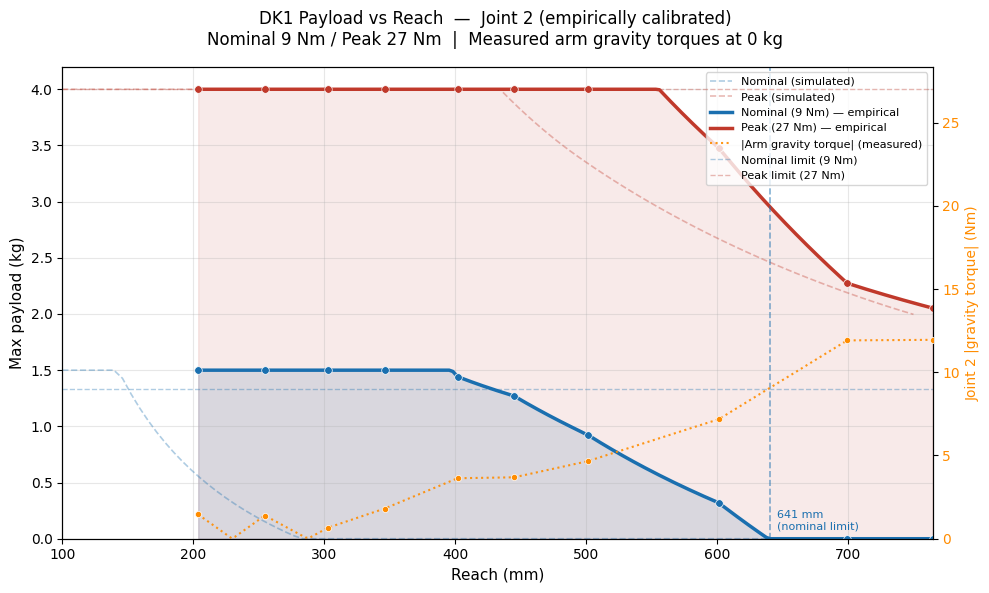

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    "DK1 Payload vs Reach  —  Joint 2 (empirically calibrated)\n"
    f"Nominal {NOMINAL_NM:.0f} Nm / Peak {PEAK_NM:.0f} Nm  |  Measured arm gravity torques at 0 kg",
    fontsize=12,
)

PAYLOAD_CAP_NOM_KG = 1.5  # empirical limit from joint 4 nominal torque

# ── Re-clip empirical curves with per-mode caps ──────────────────────────────
emp_nom_clipped  = np.minimum(emp_nom_payloads,  PAYLOAD_CAP_NOM_KG)
emp_peak_clipped = np.minimum(emp_peak_payloads, PAYLOAD_CAP_KG)

# ── Simulated curves (dashed, background reference) ──────────────────────────
# Only shown if the simulation cell was run; skip gracefully otherwise.
try:
    sim_nom  = np.minimum(nom_payloads,  PAYLOAD_CAP_NOM_KG)
    sim_peak = np.minimum(peak_payloads, PAYLOAD_CAP_KG)
    ax.plot(reaches * 1000, sim_nom,  color="#1a6faf", linewidth=1.2, linestyle="--", alpha=0.35,
            label="Nominal (simulated)")
    ax.plot(reaches * 1000, sim_peak, color="#c0392b", linewidth=1.2, linestyle="--", alpha=0.35,
            label="Peak (simulated)")
except NameError:
    pass  # simulation cell not run — skip reference curves

# ── Empirical curves (solid, primary) ─────────────────────────────────────────
ax.plot(emp_reach_dense_mm, emp_nom_clipped,  color="#1a6faf", linewidth=2.5,
        label=f"Nominal ({NOMINAL_NM:.0f} Nm) — empirical")
ax.fill_between(emp_reach_dense_mm, emp_nom_clipped, alpha=0.15, color="#1a6faf")

ax.plot(emp_reach_dense_mm, emp_peak_clipped, color="#c0392b", linewidth=2.5,
        label=f"Peak ({PEAK_NM:.0f} Nm) — empirical")
ax.fill_between(emp_reach_dense_mm, emp_peak_clipped, alpha=0.10, color="#c0392b")

# ── Measured data points ──────────────────────────────────────────────────────
emp_nom_pts  = np.minimum(
    np.maximum(0.0, (NOMINAL_NM + emp_torque_sorted) / (G * emp_ma_sorted)),
    PAYLOAD_CAP_NOM_KG,
)
emp_peak_pts = np.minimum(
    np.maximum(0.0, (PEAK_NM + emp_torque_sorted) / (G * emp_ma_sorted)),
    PAYLOAD_CAP_KG,
)
ax.scatter(emp_reach_sorted, emp_nom_pts,  color="#1a6faf", s=30, zorder=5, edgecolors="white", linewidths=0.5)
ax.scatter(emp_reach_sorted, emp_peak_pts, color="#c0392b", s=30, zorder=5, edgecolors="white", linewidths=0.5)

# ── Nominal zero-crossing ────────────────────────────────────────────────────
zero_idx = np.where(emp_nom_clipped <= 0.0)[0]
if len(zero_idx) > 0:
    zr = emp_reach_dense_mm[zero_idx[0]]
    ax.axvline(zr, color="#1a6faf", linestyle="--", linewidth=1.2, alpha=0.55)
    ax.text(zr + 5, 0.08, f"{zr:.0f} mm\n(nominal limit)", color="#1a6faf", fontsize=8)

# ── Arm gravity torque (right axis) ──────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(emp_reach_dense_mm, np.abs(emp_torque_interp), color="darkorange", linewidth=1.5,
         linestyle=":", alpha=0.9, label="|Arm gravity torque| (measured)")
ax2.scatter(emp_reach_sorted, np.abs(emp_torque_sorted), color="darkorange",
            s=20, zorder=5, edgecolors="white", linewidths=0.5)
ax2.axhline(NOMINAL_NM, color="#1a6faf", linestyle="--", linewidth=1, alpha=0.35,
            label=f"Nominal limit ({NOMINAL_NM:.0f} Nm)")
ax2.axhline(PEAK_NM,    color="#c0392b", linestyle="--", linewidth=1, alpha=0.35,
            label=f"Peak limit ({PEAK_NM:.0f} Nm)")
ax2.set_ylabel("Joint 2 |gravity torque| (Nm)", color="darkorange", fontsize=10)
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(bottom=0)

# ── Axis formatting ──────────────────────────────────────────────────────────
ax.set_xlabel("Reach (mm)", fontsize=11)
ax.set_ylabel("Max payload (kg)", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(100, emp_reach_dense_mm[-1])
ax.grid(True, alpha=0.3)

l1, lbl1 = ax.get_legend_handles_labels()
l2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lbl1 + lbl2, loc="upper right", fontsize=8)

plt.tight_layout()
out = Path("payload_reach_chart_empirical.png")
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved → {out.resolve()}")
plt.show()

## Plotting

## Side-by-side

Saved → /Users/jvg/Documents/TRLC_Local/TRLC-Coding/trlc-dk1/payload_measurement/simulation/payload_reach_chart.png


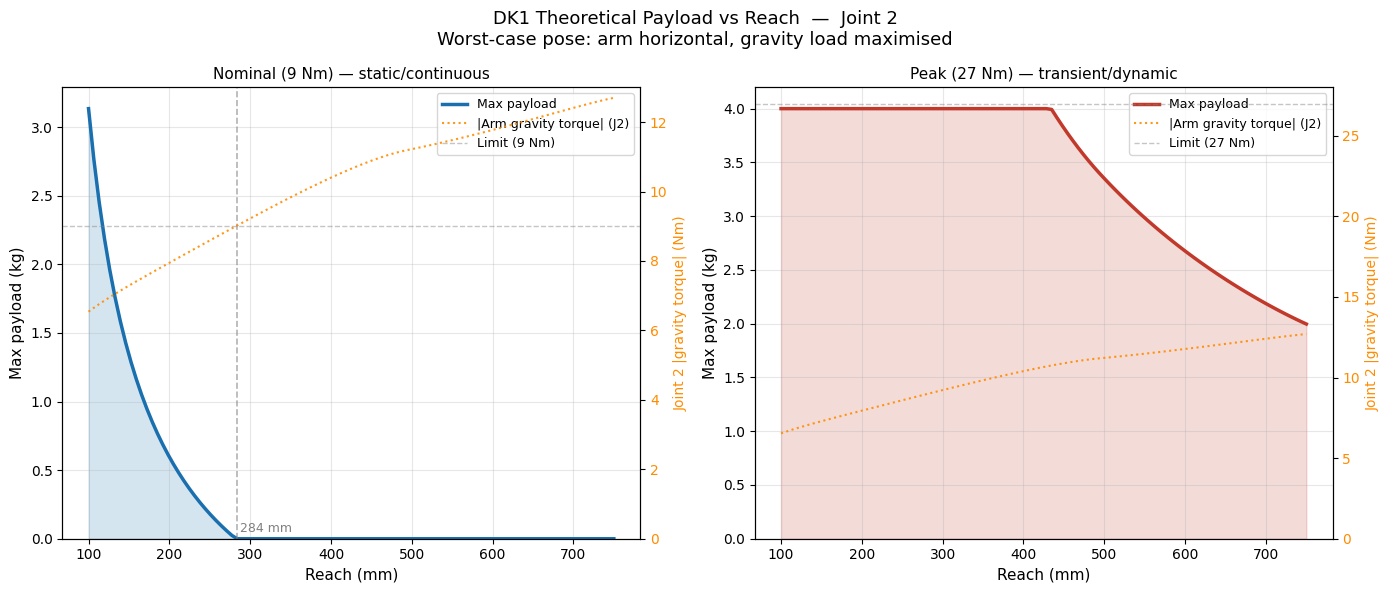

In [7]:
reach_mm    = reaches * 1000
abs_torques = np.abs(arm_torques)

PAYLOAD_CAP_KG = 4.0  # empirical limit from joint 4 peak torque
nom_plot  = np.minimum(nom_payloads,  PAYLOAD_CAP_KG)
peak_plot = np.minimum(peak_payloads, PAYLOAD_CAP_KG)

fig, (ax_nom, ax_peak) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle(
    "DK1 Theoretical Payload vs Reach  —  Joint 2\n"
    "Worst-case pose: arm horizontal, gravity load maximised",
    fontsize=13,
)

for ax, payloads, label, torque_lim, color in [
    (ax_nom,  nom_plot,  f"Nominal ({NOMINAL_NM:.0f} Nm) — static/continuous", NOMINAL_NM, "#1a6faf"),
    (ax_peak, peak_plot, f"Peak ({PEAK_NM:.0f} Nm) — transient/dynamic",       PEAK_NM,    "#c0392b"),
]:
    ax.plot(reach_mm, payloads, color=color, linewidth=2.5, label="Max payload")
    ax.fill_between(reach_mm, payloads, alpha=0.18, color=color)

    # Mark zero-payload crossing
    zero_idx = np.where(payloads <= 0.0)[0]
    if len(zero_idx) > 0:
        zr = reach_mm[zero_idx[0]]
        ax.axvline(zr, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
        ax.text(zr + 3, 0.05, f"{zr:.0f} mm", color="gray", fontsize=9)

    # Arm self-weight torque on secondary axis
    ax2 = ax.twinx()
    ax2.plot(reach_mm, abs_torques, color="darkorange", linewidth=1.5,
             linestyle=":", alpha=0.9, label="|Arm gravity torque| (J2)")
    ax2.axhline(torque_lim, color="gray", linestyle="--", linewidth=1, alpha=0.45,
                label=f"Limit ({torque_lim:.0f} Nm)")
    ax2.set_ylabel("Joint 2 |gravity torque| (Nm)", color="darkorange", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.set_ylim(bottom=0)

    ax.set_xlabel("Reach (mm)", fontsize=11)
    ax.set_ylabel("Max payload (kg)", fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    l1, lbl1 = ax.get_legend_handles_labels()
    l2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, lbl1 + lbl2, loc="upper right", fontsize=9)

plt.tight_layout()
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved → {OUT_PATH.resolve()}")
plt.show()


## On top

Saved → /Users/jvg/Documents/TRLC_Local/TRLC-Coding/trlc-dk1/payload_measurement/simulation/payload_reach_chart_overlay.png


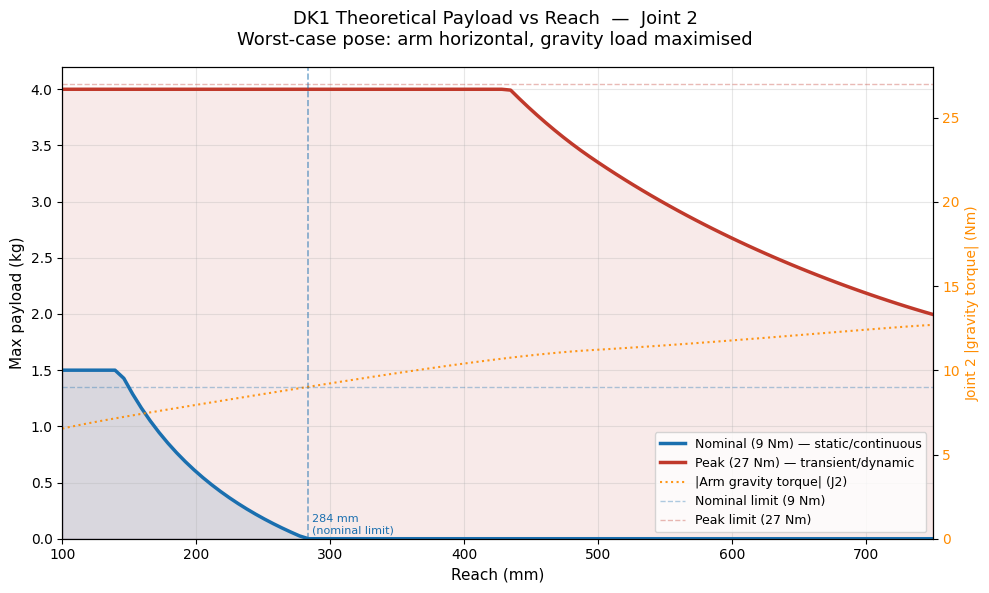

In [15]:
reach_mm    = reaches * 1000
abs_torques = np.abs(arm_torques)

PAYLOAD_CAP_PEAK_KG = 4.0  # empirical limit from joint 4 peak torque
PAYLOAD_CAP_NOM_KG = 1.5  # empirical limit from joint 4 nominal torque
nom_plot  = np.minimum(nom_payloads,  PAYLOAD_CAP_NOM_KG)
peak_plot = np.minimum(peak_payloads, PAYLOAD_CAP_PEAK_KG)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    "DK1 Theoretical Payload vs Reach  —  Joint 2\n"
    "Worst-case pose: arm horizontal, gravity load maximised",
    fontsize=13,
)

# ── payload curves (left axis) ────────────────────────────────────────────────
ax.plot(reach_mm, nom_plot,  color="#1a6faf", linewidth=2.5,
        label=f"Nominal ({NOMINAL_NM:.0f} Nm) — static/continuous")
ax.fill_between(reach_mm, nom_plot,  alpha=0.15, color="#1a6faf")

ax.plot(reach_mm, peak_plot, color="#c0392b", linewidth=2.5,
        label=f"Peak ({PEAK_NM:.0f} Nm) — transient/dynamic")
ax.fill_between(reach_mm, peak_plot, alpha=0.10, color="#c0392b")

# Mark zero-payload crossing for nominal
zero_idx = np.where(nom_plot <= 0.0)[0]
if len(zero_idx) > 0:
    zr = reach_mm[zero_idx[0]]
    ax.axvline(zr, color="#1a6faf", linestyle="--", linewidth=1.2, alpha=0.55)
    ax.text(zr + 3, 0.05, f"{zr:.0f} mm\n(nominal limit)", color="#1a6faf", fontsize=8)

ax.set_xlabel("Reach (mm)", fontsize=11)
ax.set_ylabel("Max payload (kg)", fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

# ── arm gravity torque (right axis) ───────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(reach_mm, abs_torques, color="darkorange", linewidth=1.5,
         linestyle=":", alpha=0.9, label="|Arm gravity torque| (J2)")
ax2.axhline(NOMINAL_NM, color="#1a6faf", linestyle="--", linewidth=1, alpha=0.35,
            label=f"Nominal limit ({NOMINAL_NM:.0f} Nm)")
ax2.axhline(PEAK_NM,    color="#c0392b", linestyle="--", linewidth=1, alpha=0.35,
            label=f"Peak limit ({PEAK_NM:.0f} Nm)")
ax2.set_ylabel("Joint 2 |gravity torque| (Nm)", color="darkorange", fontsize=10)
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(bottom=0)
ax2.set_xlim(left=100)
ax2.set_xlim(right=750)

# ── combined legend ────────────────────────────────────────────────────────────
l1, lbl1 = ax.get_legend_handles_labels()
l2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lbl1 + lbl2, loc="lower right", fontsize=9)

plt.tight_layout()
out = OUT_PATH.with_name("payload_reach_chart_overlay.png")
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved → {out.resolve()}")
plt.show()
